# (1+1)D Korteweg–De Vries (KdV) Equation with Physics-Informed Neural Networks

The **KdV equation** models the dynamics of solitary waves (solitons):

$$u_t + \eta\, u\, u_x + \mu^2\, u_{xxx} = 0, \quad t \in (0, 1),\ x \in (-1, 1)$$

**Initial condition:**
$$u(x, 0) = \cos(\pi x)$$

**Periodic boundary conditions:**
$$u(t, -1) = u(t, 1)$$

**Classical parameters** (η = 1, μ = 0.022).


In [1]:
import pinns

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import RegularGridInterpolator


## Domain
Space-time domain: $x \in [-1, 1]$, $t \in [0, 1]$. Periodic BC on $x$.


In [2]:
domain = pinns.DomainCubic(
    space=[(-1.0, 1.0)],   # x
    time =[0.0,   1.0],    # t
)

domain.add_periodic("x", "periodic")


## PDE Residual

$$\mathcal{R} = u_t + \eta\, u\, u_x + \mu^2\, u_{xxx} = 0$$


In [3]:
problem = pinns.ProblemStrong(domain=domain, output_names=["u"])

def kdv_residual(X, U, params, derivative=None):
    eta = params['fixed']['eta']
    mu2 = params['fixed']['mu2']

    u_t   = derivative(U, X, 0, (1,))           # ∂u/∂t
    u_x   = derivative(U, X, 0, (0,))           # ∂u/∂x
    u_xxx = derivative(U, X, 0, (0, 0, 0))      # ∂³u/∂x³

    return u_t + eta * U * u_x + mu2 * u_xxx    # (N,1)

problem.add_inner(kdv_residual, name="pde")

def u_initial(X):
    x = X[:, 0:1]
    return jnp.cos(jnp.pi * x)

problem.add_initial(u_initial, name="initial")

problem.add_fixed("eta", 1.0)
problem.add_fixed("mu2", 0.022**2)


ProblemStrong(domain=DomainCubic, n_dims=2, n_outputs=1, inner=1, boundary=0, initial=1, fixed=['eta', 'mu2'], inferred=[])

### Reference Solution (pseudo-spectral)

The KdV equation with periodic BCs is solved spectrally via FFT.
In Fourier space, with $\hat{u}_k$ the $k$-th mode:

$$\partial_t \hat{u}_k = -\frac{i\eta k}{2}\,\widehat{u^2}_k + i\mu^2 k^3\, \hat{u}_k$$

The linear dispersion term $i\mu^2 k^3$ is integrated exactly (integrating factor) to avoid stiffness.


In [4]:
eta_val = 1.0
mu_val  = 0.022
Nx   = 512      # must be even for rfft
Nt   = 200

x_ref = np.linspace(-1, 1, Nx, endpoint=False)   # periodic grid
t_ref = np.linspace(0, 1, Nt)

# Wavenumbers for domain length L = 2
k  = np.fft.rfftfreq(Nx, d=2.0 / Nx) * (2 * np.pi)
k3 = k ** 3
nk = len(k)

def rhs_kdv(t, y):
    u_hat = y[:nk] + 1j * y[nk:]
    u     = np.fft.irfft(u_hat, n=Nx)
    # Nonlinear term: eta * u * u_x = eta * (u²)_x / 2  →  i*eta*k/2 * FFT(u²)
    nl    = np.fft.rfft(u * u)
    duhat = -1j * eta_val * k / 2.0 * nl + 1j * mu_val**2 * k3 * u_hat
    return np.concatenate([duhat.real, duhat.imag])

def state(u_hat):
    return np.concatenate([u_hat.real, u_hat.imag])

u0  = np.cos(np.pi * x_ref)
sol = solve_ivp(
    rhs_kdv,
    t_span=(0, 1),
    y0=state(np.fft.rfft(u0)),
    t_eval=t_ref,
    method='RK45',
    rtol=1e-8, atol=1e-10,
    max_step=1e-3,
)

# U_ref shape: (Nt, Nx)
U_ref = np.array([
    np.fft.irfft(sol.y[:nk, i] + 1j * sol.y[nk:, i], n=Nx)
    for i in range(Nt)
])

print(f"Reference solver: {sol.message}")
print(f"U_ref shape: {U_ref.shape}   range: [{U_ref.min():.4f}, {U_ref.max():.4f}]")

# Interpolant: X[:,0]=x, X[:,1]=t → (N,1)
_interp = RegularGridInterpolator(
    (t_ref, x_ref), U_ref,
    method='linear', bounds_error=False, fill_value=None,
)

def u_reference(X):
    return _interp(np.stack([X[:, 1], X[:, 0]], axis=1))[:, None]  # (N,1)

problem.add_solution(u_reference)


Reference solver: The solver successfully reached the end of the integration interval.
U_ref shape: (200, 512)   range: [-1.0000, 2.6307]


ProblemStrong(domain=DomainCubic, n_dims=2, n_outputs=1, inner=1, boundary=0, initial=1, fixed=['eta', 'mu2'], inferred=[])

## Network Architecture

Fourier feature embedding + FNN with `tanh` output activation to keep predictions bounded.
The KdV solution stays within the amplitude range $\approx [-1.5, 1.5]$.


In [5]:
network = pinns.ModelBase(domain, 1)

network.add(
    pinns.PeriodicEmbedding("x")
)
network.add(
    pinns.FourierFeatures(256, sigma=1.0)
)
network.add(
    pinns.PirateNet(256, 3, rwf_mu=1, rwf_sigma=0.1)
)

ModelBase(output_dim=1)
  [PeriodicEmbedding_0] PeriodicEmbedding(axis=0, k=[1], freq=3.1416, input_dim=2, output_dim=3)
  [RandomFourierFeatures_1] RandomFourierFeatures(input_dim=3, n_features=256, sigma=1.0, encode_time=False, adaptive=True)
  [PirateNet_2] PirateNet(input_dim=512, hidden_dim=256, n_blocks=3, output_dim=1)

## Training

Three schedulers mirror the jaxpi KdV setup:

- **Causal weighting** (`SchedulerCausal`): time-sorts the PDE collocation points and exponentially down-weights future chunks until earlier chunks converge ($\varepsilon = 1.0$, 16 chunks).
- **Grad-norm balancing** (`SchedulerGradNorm`): adapts per-term loss weights every 1 000 epochs so that their gradient magnitudes stay proportional.

- **Curriculum + resample**: the sampled time window grows from $t\in[0,0.1]$ to $[0,1]$ over 10 stages of 5 000 epochs each; collocation points are resampled every 1 000 epochs.

Starting training for 500000 epochs (JIT-compiled)...


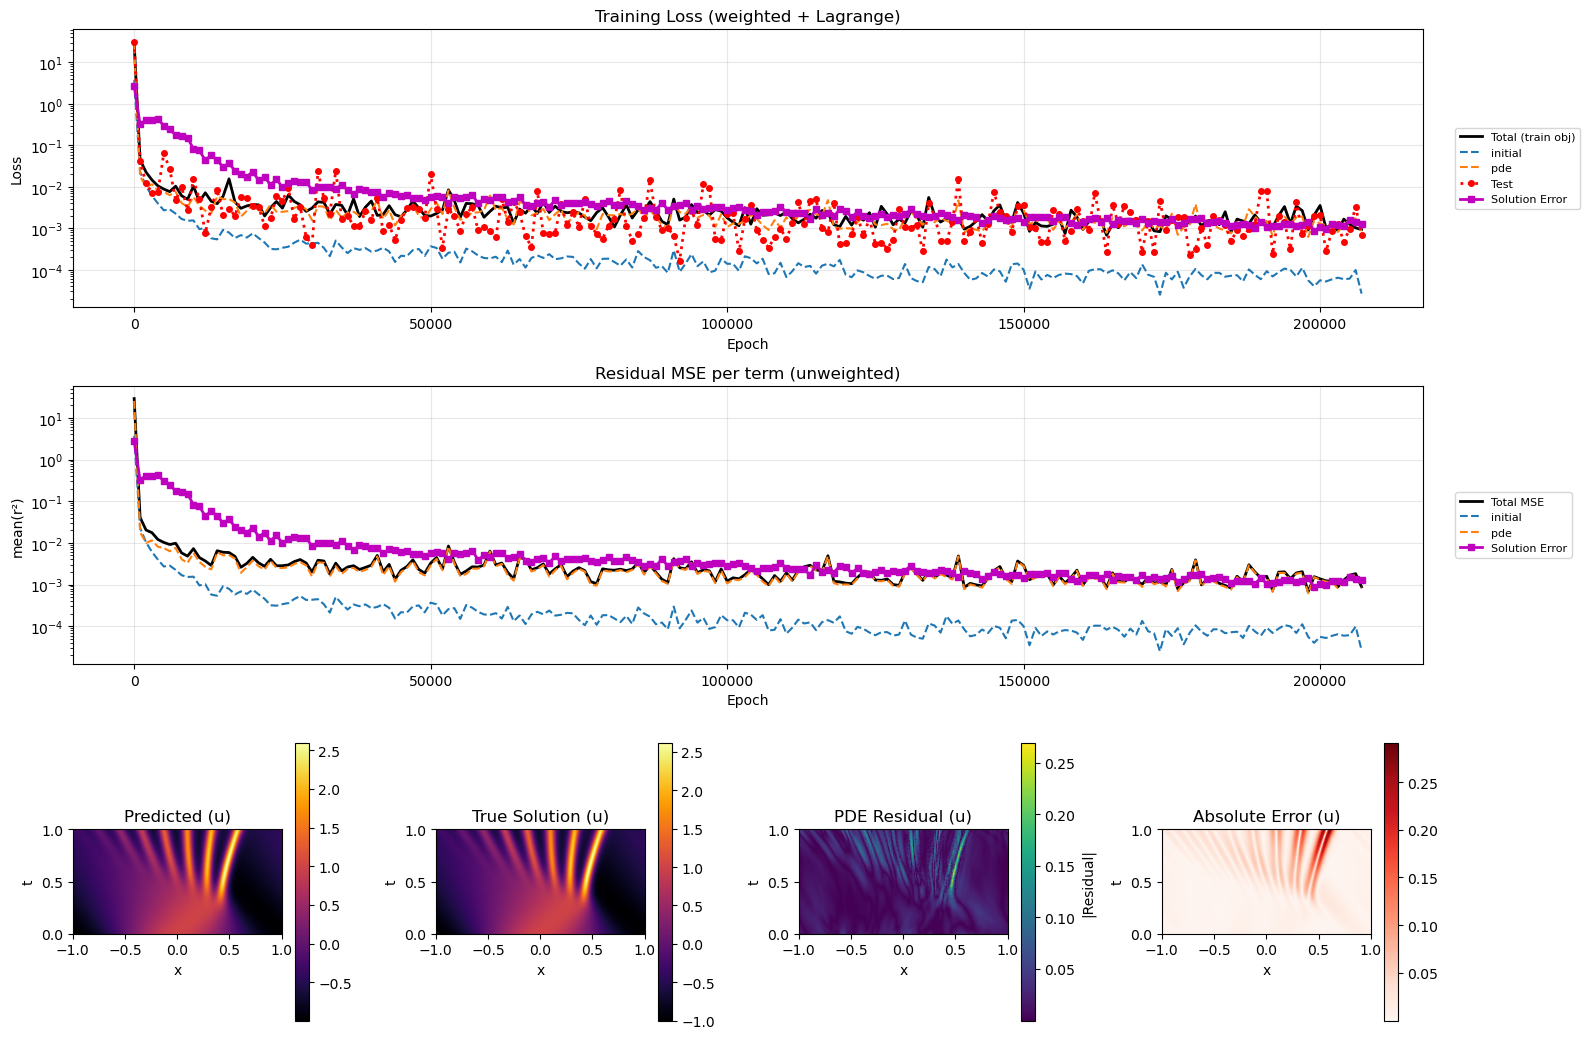

Epoch 0/500000 | Loss: 2.90e+01 | MSE: 2.90e+01 | Terms: [initial: 3.72e+00, pde: 2.53e+01] | Test Loss: 3.11e+01 | Error: 2.76e+00 | Time: 0.0s
Epoch 1000/500000 | Loss: 4.45e-02 | MSE: 4.09e-02 | Terms: [initial: 2.28e-02, pde: 1.80e-02] | Test Loss: 4.13e-02 | Error: 3.19e-01 | Time: 39.0s
Epoch 2000/500000 | Loss: 2.26e-02 | MSE: 2.04e-02 | Terms: [initial: 1.04e-02, pde: 9.98e-03] | Test Loss: 1.22e-02 | Error: 4.14e-01 | Time: 53.4s
Epoch 3000/500000 | Loss: 1.46e-02 | MSE: 1.76e-02 | Terms: [initial: 6.08e-03, pde: 1.15e-02] | Test Loss: 7.23e-03 | Error: 3.97e-01 | Time: 67.6s
Epoch 4000/500000 | Loss: 1.05e-02 | MSE: 1.21e-02 | Terms: [initial: 3.98e-03, pde: 8.09e-03] | Test Loss: 7.43e-03 | Error: 4.34e-01 | Time: 81.7s
Epoch 5000/500000 | Loss: 8.82e-03 | MSE: 1.03e-02 | Terms: [initial: 2.72e-03, pde: 7.55e-03] | Test Loss: 6.41e-02 | Error: 2.98e-01 | Time: 96.0s
Epoch 6000/500000 | Loss: 7.65e-03 | MSE: 9.15e-03 | Terms: [initial: 2.85e-03, pde: 6.30e-03] | Test Loss: 2.

KeyboardInterrupt: 

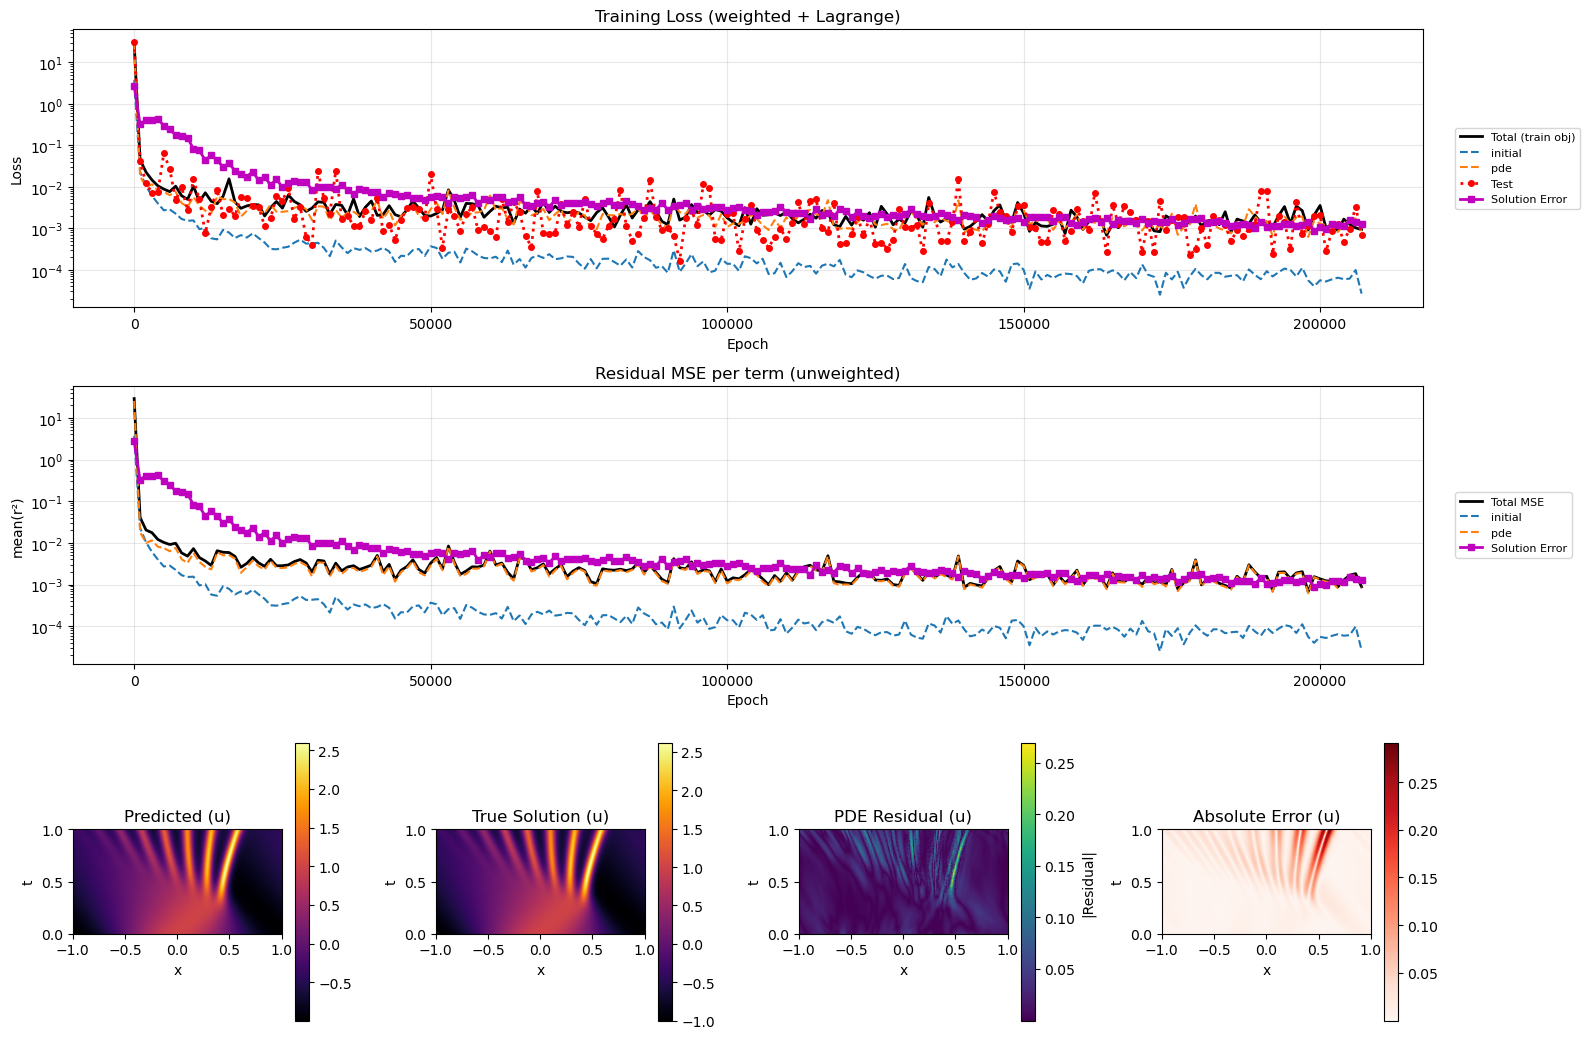

In [6]:
trainer = pinns.Trainer(problem, network)

trainer.compile(
    problem = {
        "pde":      {"train": 1000, "test": 10, "weight": 1.0},
        "initial":  {"train": 200,  "test": 10, "weight": 1.0},
    },
    optimizer=pinns.SOAPOptimizer(),
    schedulers=[
        pinns.SchedulerResample(1),
        pinns.SchedulerCausal(term="pde", tol=1.0, n_chunks=16, t_col=1),
    ],
    epochs     = 500000,
    print_each = 1000,
)

trainer.train()